In [1]:
#Importing the libraries
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read the dataset
df = pd.read_csv(r"C:\Users\VINIT\NYCTaxiFares.csv")
df

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2010-04-19 08:17:56 UTC,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1
1,2010-04-17 15:43:53 UTC,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1
2,2010-04-17 11:23:26 UTC,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2
3,2010-04-11 21:25:03 UTC,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1
4,2010-04-17 02:19:01 UTC,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1
...,...,...,...,...,...,...,...,...
119995,2010-04-18 14:33:03 UTC,15.3,1,-73.955857,40.784590,-73.981941,40.736789,1
119996,2010-04-23 10:27:48 UTC,15.3,1,-73.996329,40.772727,-74.049890,40.740413,1
119997,2010-04-18 18:50:40 UTC,12.5,1,-73.988574,40.749772,-74.011541,40.707799,3
119998,2010-04-13 08:14:44 UTC,4.9,0,-74.004449,40.724529,-73.992697,40.730765,1


In [3]:
df.head()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2010-04-19 08:17:56 UTC,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1
1,2010-04-17 15:43:53 UTC,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1
2,2010-04-17 11:23:26 UTC,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2
3,2010-04-11 21:25:03 UTC,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1
4,2010-04-17 02:19:01 UTC,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1


In [4]:
df.tail()

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
119995,2010-04-18 14:33:03 UTC,15.3,1,-73.955857,40.784590,-73.981941,40.736789,1
119996,2010-04-23 10:27:48 UTC,15.3,1,-73.996329,40.772727,-74.049890,40.740413,1
119997,2010-04-18 18:50:40 UTC,12.5,1,-73.988574,40.749772,-74.011541,40.707799,3
119998,2010-04-13 08:14:44 UTC,4.9,0,-74.004449,40.724529,-73.992697,40.730765,1
119999,2010-04-17 16:00:14 UTC,5.3,0,-73.955415,40.771920,-73.967623,40.763015,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   pickup_datetime    120000 non-null  object 
 1   fare_amount        120000 non-null  float64
 2   fare_class         120000 non-null  int64  
 3   pickup_longitude   120000 non-null  float64
 4   pickup_latitude    120000 non-null  float64
 5   dropoff_longitude  120000 non-null  float64
 6   dropoff_latitude   120000 non-null  float64
 7   passenger_count    120000 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 7.3+ MB


In [6]:
df.describe()

,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,10.040326,0.333333,-73.976626,40.751443,-73.974501,40.751695,1.347167
std,7.500134,0.471406,0.031497,0.025821,0.032419,0.030279,0.759263
min,2.500000,0.000000,-74.465447,40.121653,-74.443323,40.164927,1.000000
25%,5.700000,0.000000,-73.992386,40.736594,-73.991478,40.735914,1.000000
50%,7.700000,0.000000,-73.982084,40.753661,-73.980411,40.754441,1.000000
75%,11.300000,1.000000,-73.968710,40.768020,-73.965500,40.768880,1.000000
max,49.900000,1.000000,-73.311845,40.981292,-73.496140,40.993498,5.000000


In [7]:
df.isnull().sum()

pickup_datetime      0
fare_amount          0
fare_class           0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [8]:
#Convert pickup_datetime into day and hour
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['day'] = df['pickup_datetime'].dt.day
df['hour'] = df['pickup_datetime'].dt.hour

In [9]:
#Drop the pickup_datetime column and use day and hour columns
df = df.drop(['pickup_datetime','fare_amount'],axis = 1)

In [10]:
#Check the correlation
corr = df.corr()
corr

,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,day,hour
fare_class,1.000000,0.163574,-0.104847,0.220660,-0.101500,0.032022,0.015270,-0.016007
pickup_longitude,0.163574,1.000000,0.071137,0.287627,0.072225,-0.013618,-0.025344,0.025750
pickup_latitude,-0.104847,0.071137,1.000000,0.074658,0.402102,-0.030190,-0.023598,0.037468
dropoff_longitude,0.220660,0.287627,0.074658,1.000000,0.165349,-0.007644,-0.013098,-0.054598
dropoff_latitude,-0.101500,0.072225,0.402102,0.165349,1.000000,-0.015962,-0.016741,0.024639
passenger_count,0.032022,-0.013618,-0.030190,-0.007644,-0.015962,1.000000,0.026230,0.020893
day,0.015270,-0.025344,-0.023598,-0.013098,-0.016741,0.026230,1.000000,-0.084113
hour,-0.016007,0.025750,0.037468,-0.054598,0.024639,0.020893,-0.084113,1.000000


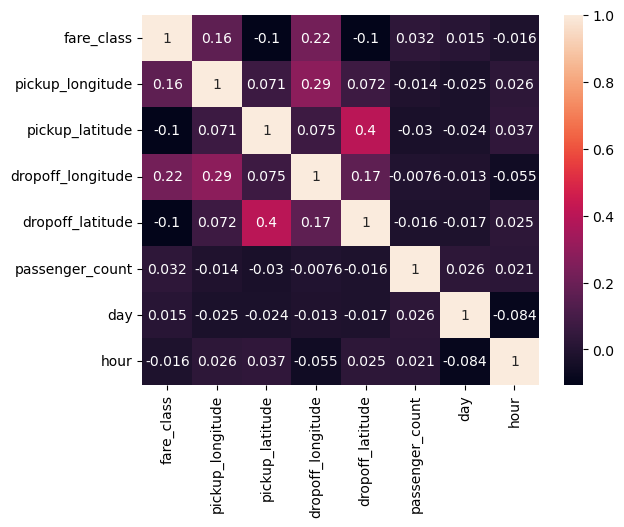

In [11]:
#Show the correlation using heatmap
sns.heatmap(corr, annot =True, cmap="rocket")
plt.show()

In [12]:
#Dividing the data into x and y
x = df.drop('fare_class', axis = 1)
y = df['fare_class']
x

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,day,hour
0,-73.992365,40.730521,-73.975499,40.744746,1,19,8
1,-73.990078,40.740558,-73.974232,40.744114,1,17,15
2,-73.994149,40.751118,-73.960064,40.766235,2,17,11
3,-73.990485,40.756422,-73.971205,40.748192,1,11,21
4,-73.990976,40.734202,-73.905956,40.743115,1,17,2
...,...,...,...,...,...,...,...
119995,-73.955857,40.784590,-73.981941,40.736789,1,18,14
119996,-73.996329,40.772727,-74.049890,40.740413,1,23,10
119997,-73.988574,40.749772,-74.011541,40.707799,3,18,18
119998,-74.004449,40.724529,-73.992697,40.730765,1,13,8


In [13]:
y

0         0
1         0
2         1
3         0
4         1
         ..
119995    1
119996    1
119997    1
119998    0
119999    0
Name: fare_class, Length: 120000, dtype: int64

In [14]:
#Splitting the data
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)
x_train

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,day,hour
53541,-73.974676,40.793007,-73.984200,40.780026,1,23,17
41728,-73.981201,40.743717,-73.971871,40.751428,2,21,22
74819,-73.981268,40.753525,-73.947819,40.772779,2,16,15
106459,-73.978032,40.757389,-73.998894,40.734191,1,15,20
63062,-73.986337,40.746615,-73.997458,40.684333,2,13,17
...,...,...,...,...,...,...,...
110268,-73.987448,40.768680,-73.990188,40.751074,1,17,18
119879,-74.013170,40.703437,-74.004829,40.707020,1,14,22
103694,-74.003642,40.707221,-73.991537,40.744665,3,11,13
860,-73.988848,40.730722,-73.992248,40.742690,1,17,11


In [15]:
x_test

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,day,hour
71787,-73.992393,40.737721,-74.002919,40.740919,1,22,6
67218,-73.961832,40.779689,-73.967458,40.763274,4,14,15
54066,-73.844216,40.721319,-73.822399,40.716225,1,17,0
7168,-73.963337,40.803710,-73.900326,40.859016,1,24,19
29618,-73.981609,40.773532,-73.978986,40.764120,1,19,6
...,...,...,...,...,...,...,...
17283,-73.960016,40.770380,-73.943363,40.786907,1,21,1
89286,-73.982744,40.741989,-73.906104,40.694230,1,24,7
47263,-73.977366,40.752466,-73.992844,40.721439,4,17,19
83913,-73.959492,40.780322,-73.993883,40.751684,1,15,12


In [16]:
y_train

53541     0
41728     0
74819     1
106459    1
63062     1
         ..
110268    0
119879    0
103694    1
860       0
15795     0
Name: fare_class, Length: 96000, dtype: int64

In [17]:
y_test

71787    0
67218    0
54066    0
7168     1
29618    0
        ..
17283    0
89286    1
47263    1
83913    1
74735    0
Name: fare_class, Length: 24000, dtype: int64

In [18]:
#Create the model
model = LogisticRegression()

In [19]:
#train the model
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
#Model predict the result
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(24000,))

In [21]:
#Training Score
model.score(x_train,y_train)

0.66740625

In [22]:
#Testing Score
model.score(x_test,y_test)

0.667875

In [23]:
#Accuracy
acc = accuracy_score(y_test,y_pred)
acc

0.667875

In [24]:
acc*100

66.7875

In [25]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[16003,     0],
       [ 7971,    26]])

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80     16003
           1       1.00      0.00      0.01      7997

    accuracy                           0.67     24000
   macro avg       0.83      0.50      0.40     24000
weighted avg       0.78      0.67      0.54     24000

